Pandas time: 3.962953567504883
Dask time: 2.334076404571533


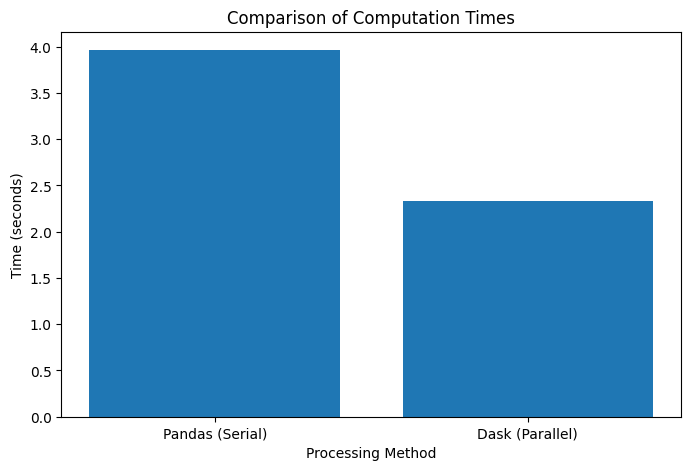

In [1]:
import time
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt

file_path = "Trips_by_Distance.csv"

# pandas timing
start_pd = time.time()
df_pd = pd.read_csv(file_path)
df_pd = df_pd[df_pd["Level"] == "National"]
df_pd["Population Staying at Home"] = df_pd["Population Staying at Home"].fillna(
    df_pd["Population Staying at Home"].mean()
)
result_pd = df_pd.groupby("Week")["Population Staying at Home"].mean()
end_pd = time.time()
pandas_time = end_pd - start_pd

# dask timing
start_dask = time.time()
df_dask = dd.read_csv(
    file_path,
    assume_missing=True,
    dtype={"County Name": "object", "State Postal Code": "object"}
)
df_dask = df_dask[df_dask["Level"] == "National"]
df_dask["Population Staying at Home"] = df_dask["Population Staying at Home"].fillna(
    df_dask["Population Staying at Home"].mean()
)
result_dask = df_dask.groupby("Week")["Population Staying at Home"].mean().compute()
end_dask = time.time()
dask_time = end_dask - start_dask

print("Pandas time:", pandas_time)
print("Dask time:", dask_time)

# plot
methods = ["Pandas (Serial)", "Dask (Parallel)"]
times = [pandas_time, dask_time]

plt.figure(figsize=(8, 5))
plt.bar(methods, times)
plt.xlabel("Processing Method")
plt.ylabel("Time (seconds)")
plt.title("Comparison of Computation Times")
plt.show()